In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df_2425 = pd.read_csv("pl2425.csv")
df_2324 = pd.read_csv("pl2324.csv")

In [10]:
print(df_2425.shape)
print(df_2324.shape)

(562, 57)
(580, 34)


In [11]:
df_2324.columns.tolist()

['Player',
 'Nation',
 'Pos',
 'Age',
 'MP',
 'Starts',
 'Min',
 '90s',
 'Gls',
 'Ast',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'xG',
 'npxG',
 'xAG',
 'npxG+xAG',
 'PrgC',
 'PrgP',
 'PrgR',
 'Gls_90',
 'Ast_90',
 'G+A_90',
 'G-PK_90',
 'G+A-PK_90',
 'xG_90',
 'xAG_90',
 'xG+xAG_90',
 'npxG_90',
 'npxG+xAG_90',
 'Team']

In [12]:
df_2324 = df_2324.rename(columns={
    'Player': 'Player Name',
    'Team': 'Club',
    'Gls': 'Goals',
    'Ast': 'Assists',
    'Min': 'Minutes'
})

In [13]:
chelsea_2425 = df_2425[df_2425['Club'] == 'Chelsea'].copy()
chelsea_2324 = df_2324[df_2324['Club'] == 'Chelsea'].copy()

In [14]:
print("Chelsea 24/25 players:", len(chelsea_2425))
print("Chelsea 23/24 players:", len(chelsea_2324))

Chelsea 24/25 players: 28
Chelsea 23/24 players: 32


In [41]:
chelsea_2425['Goal Contributions'] = chelsea_2425['Goals'] + chelsea_2425['Assists']
chelsea_2324['Goal Contributions'] = chelsea_2324['Goals'] + chelsea_2324['Assists']

In [42]:
top_2425 = chelsea_2425[['Player Name', 'Goals', 'Assists', 'Goal Contributions']].sort_values('Goal Contributions', ascending=False).head(10)

In [58]:
chelsea_2324['Goals'] = chelsea_2324['Goals'].fillna(0).astype(int)

In [59]:
chelsea_2324['Assists'] = chelsea_2324['Assists'].fillna(0).astype(int)
chelsea_2324['Goal Contributions'] = chelsea_2324['Goal Contributions'].fillna(0).astype(int)

In [60]:
top_2324 = chelsea_2324[['Player Name', 'Goals', 'Assists', 'Goal Contributions']].sort_values('Goal Contributions', ascending=False).head(10)
print("=== Pochettino 23/24 - Top Contributors ===")
print(top_2324.to_string())

=== Pochettino 23/24 - Top Contributors ===
        Player Name  Goals  Assists  Goal Contributions
83      Cole Palmer     22       11                  33
82  Nicolas Jackson     14        5                  19
80  Conor Gallagher      5        7                  12
88  Raheem Sterling      8        4                  12
92  Mykhailo Mudryk      5        2                   7
95     Noni Madueke      5        2                   7
91       Malo Gusto      0        6                   6
86   Enzo Fernández      3        2                   5
81   Moisés Caicedo      1        3                   4
85     Thiago Silva      3        1                   4


In [61]:
print("=== Maresca 24/25 - Top Contributors ===")
print(top_2425.to_string())
print("\n=== Pochettino 23/24 - Top Contributors ===")
print(top_2324.to_string())

=== Maresca 24/25 - Top Contributors ===
         Player Name  Goals  Assists  Goal Contributions
141      Cole Palmer     15        8                  23
155  Nicolas Jackson     10        5                  15
142   Enzo Fernández      6        7                  13
156     Noni Madueke      7        3                  10
150   Marc Cucurella      5        1                   6
157       Pedro Neto      4        0                   4
164  Trevoh Chalobah      3        1                   4
153   Moisés Caicedo      1        2                   3
144     Jadon Sancho      3        0                   3
148     Levi Colwill      2        1                   3

=== Pochettino 23/24 - Top Contributors ===
        Player Name  Goals  Assists  Goal Contributions
83      Cole Palmer     22       11                  33
82  Nicolas Jackson     14        5                  19
80  Conor Gallagher      5        7                  12
88  Raheem Sterling      8        4                  12
92  Myk

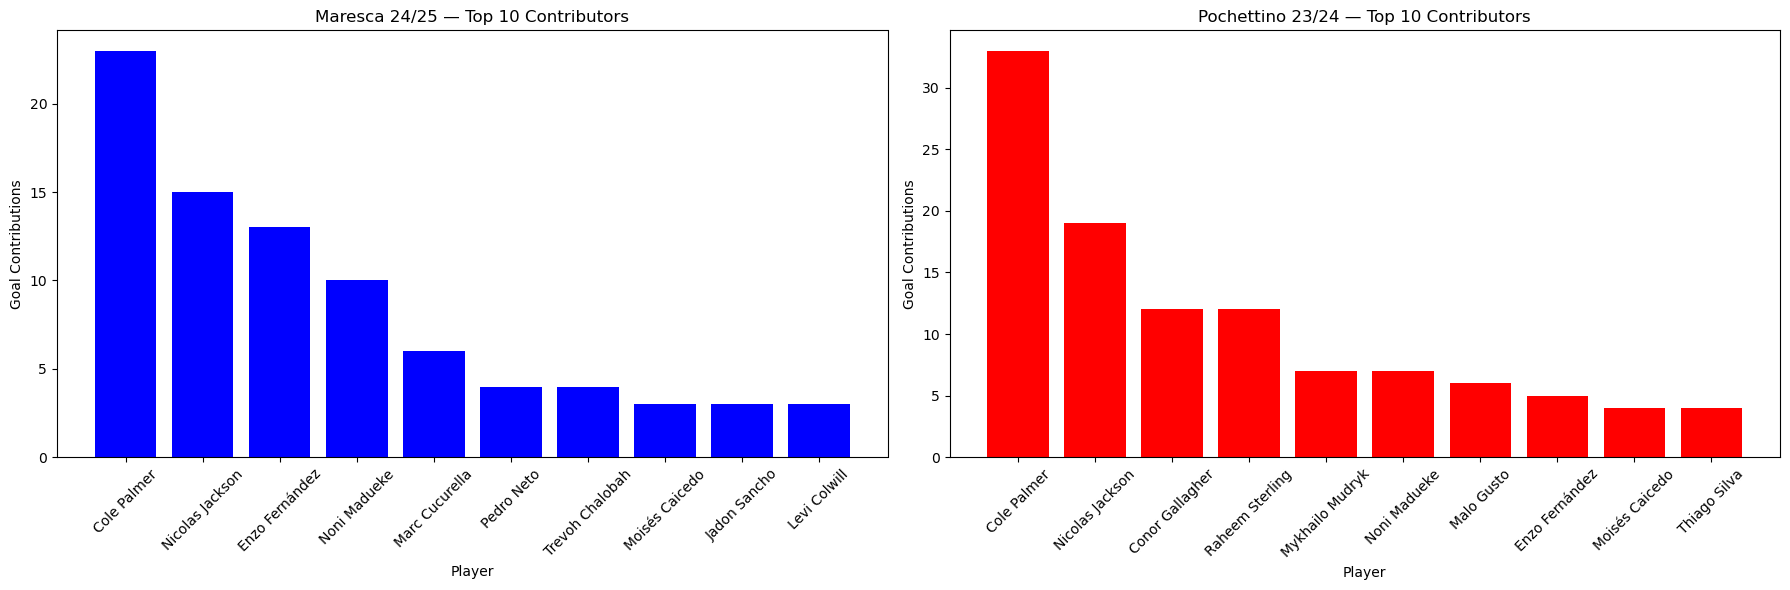

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.bar(top_2425['Player Name'], top_2425['Goal Contributions'], color='blue')
ax1.set_title('Maresca 24/25 — Top 10 Contributors')
ax1.set_xlabel('Player')
ax1.set_ylabel('Goal Contributions')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(top_2324['Player Name'], top_2324['Goal Contributions'], color='red')
ax2.set_title('Pochettino 23/24 — Top 10 Contributors')
ax2.set_xlabel('Player')
ax2.set_ylabel('Goal Contributions')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [47]:
print("=== Team Totals Comparison ===")
print(f"Maresca 24/25 - Total Goals: {chelsea_2425['Goals'].sum()}")
print(f"Maresca 24/25 - Total Assists: {chelsea_2425['Assists'].sum()}")
print(f"Maresca 24/25 - Total Contributions: {chelsea_2425['Goal Contributions'].sum()}")
print()
print(f"Pochettino 23/24 - Total Goals: {chelsea_2324['Goals'].sum()}")
print(f"Pochettino 23/24 - Total Assists: {chelsea_2324['Assists'].sum()}")
print(f"Pochettino 23/24 - Total Contributions: {chelsea_2324['Goal Contributions'].sum()}")

=== Team Totals Comparison ===
Maresca 24/25 - Total Goals: 63
Maresca 24/25 - Total Assists: 32
Maresca 24/25 - Total Contributions: 95

Pochettino 23/24 - Total Goals: 76
Pochettino 23/24 - Total Assists: 51
Pochettino 23/24 - Total Contributions: 127


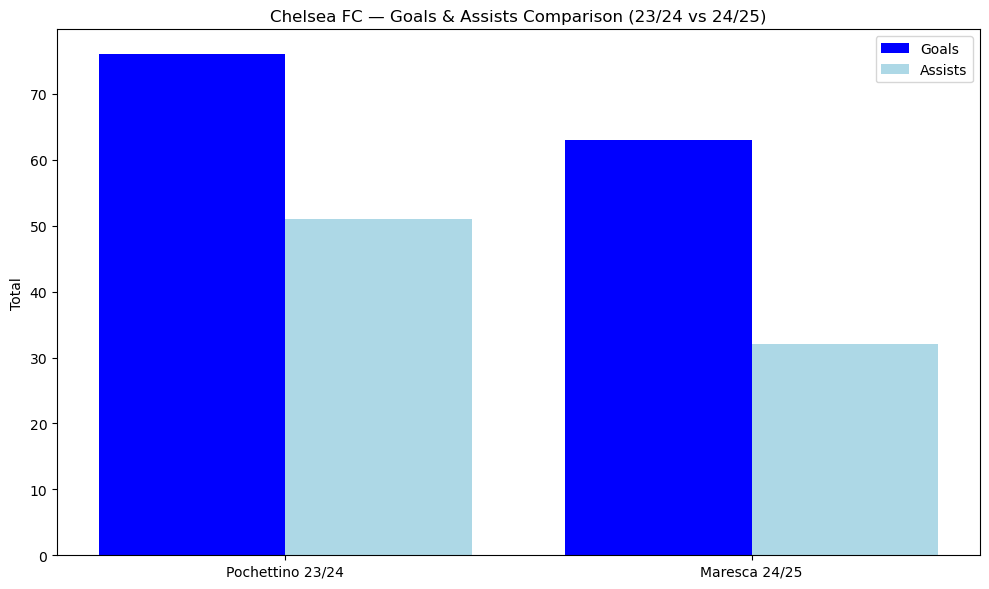

In [48]:
seasons = ['Pochettino 23/24', 'Maresca 24/25']
goals = [76, 63]
assists = [51, 32]

x = range(len(seasons))

plt.figure(figsize=(10, 6))
plt.bar(x, goals, width=0.4, label='Goals', color='blue', align='center')
plt.bar([i + 0.4 for i in x], assists, width=0.4, label='Assists', color='lightblue', align='center')
plt.xticks([i + 0.2 for i in x], seasons)
plt.title('Chelsea FC — Goals & Assists Comparison (23/24 vs 24/25)')
plt.ylabel('Total')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
print("=== Defensive Comparison ===")
print(f"Maresca 24/25 - Total Yellow Cards: {chelsea_2425['Yellow Cards'].sum()}")
print(f"Pochettino 23/24 - Total Yellow Cards: {chelsea_2324['CrdY'].sum()}")

=== Defensive Comparison ===
Maresca 24/25 - Total Yellow Cards: 99
Pochettino 23/24 - Total Yellow Cards: 108.0


In [50]:
chelsea_2425.columns.tolist()

['Player Name',
 'Club',
 'Nationality',
 'Position',
 'Appearances',
 'Minutes',
 'Goals',
 'Assists',
 'Shots',
 'Shots On Target',
 'Conversion %',
 'Big Chances Missed',
 'Hit Woodwork',
 'Offsides',
 'Touches',
 'Passes',
 'Successful Passes',
 'Passes%',
 'Crosses',
 'Successful Crosses',
 'Crosses %',
 'fThird Passes',
 'Successful fThird Passes',
 'fThird Passes %',
 'Through Balls',
 'Carries',
 'Progressive Carries',
 'Carries Ended with Goal',
 'Carries Ended with Assist',
 'Carries Ended with Shot',
 'Carries Ended with Chance',
 'Possession Won',
 'Dispossessed',
 'Clean Sheets',
 'Clearances',
 'Interceptions',
 'Blocks',
 'Tackles',
 'Ground Duels',
 'gDuels Won',
 'gDuels %',
 'Aerial Duels',
 'aDuels Won',
 'aDuels %',
 'Goals Conceded',
 'xGoT Conceded',
 'Own Goals',
 'Fouls',
 'Yellow Cards',
 'Red Cards',
 'Saves',
 'Saves %',
 'Penalties Saved',
 'Clearances Off Line',
 'Punches',
 'High Claims',
 'Goals Prevented',
 'Goal Contributions']

In [51]:
chelsea_2324.columns.tolist()

['Player Name',
 'Nation',
 'Pos',
 'Age',
 'MP',
 'Starts',
 'Minutes',
 '90s',
 'Goals',
 'Assists',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'xG',
 'npxG',
 'xAG',
 'npxG+xAG',
 'PrgC',
 'PrgP',
 'PrgR',
 'Gls_90',
 'Ast_90',
 'G+A_90',
 'G-PK_90',
 'G+A-PK_90',
 'xG_90',
 'xAG_90',
 'xG+xAG_90',
 'npxG_90',
 'npxG+xAG_90',
 'Club',
 'Goal Contributions']

In [52]:
print("=== Season Summary Comparison ===")
print()
print("Pochettino 23/24:")
print("- League Position: 6th")
print("- Total Goals Scored: 76")
print("- Total Goal Contributions: 127")
print("- Goals Conceded: 63 (Premier League record)")
print()
print("Maresca 24/25:")
print("- League Position: 4th (Champions League qualified)")
print("- Total Goals Scored: 63")
print("- Total Goal Contributions: 95")
print("- Goals Conceded: 39 (Premier League record)")

=== Season Summary Comparison ===

Pochettino 23/24:
- League Position: 6th
- Total Goals Scored: 76
- Total Goal Contributions: 127
- Goals Conceded: 63 (Premier League record)

Maresca 24/25:
- League Position: 4th (Champions League qualified)
- Total Goals Scored: 63
- Total Goal Contributions: 95
- Goals Conceded: 39 (Premier League record)


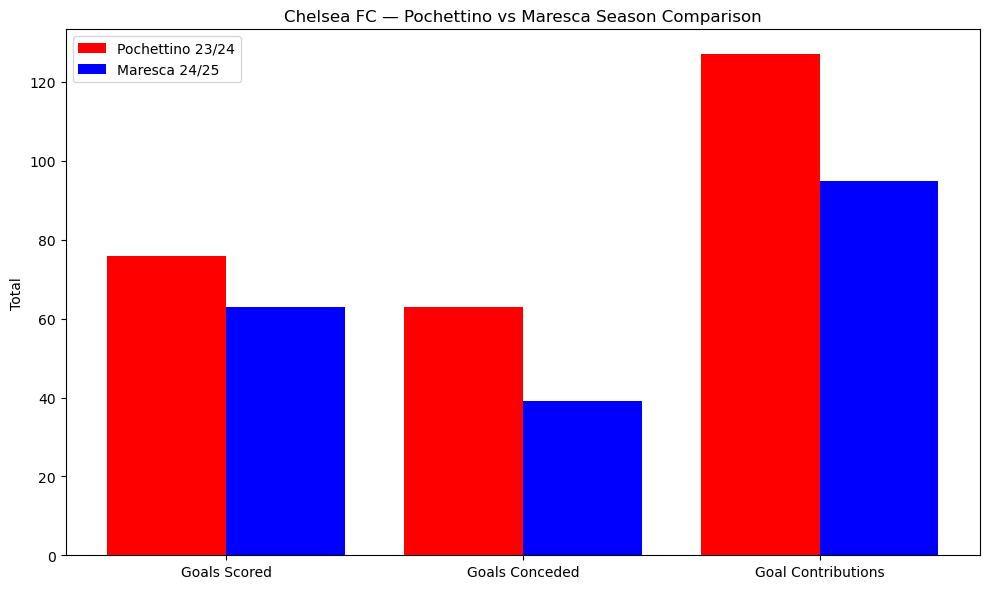

In [53]:
categories = ['Goals Scored', 'Goals Conceded', 'Goal Contributions']
pochettino = [76, 63, 127]
maresca = [63, 39, 95]

x = range(len(categories))

plt.figure(figsize=(10, 6))
plt.bar([i - 0.2 for i in x], pochettino, width=0.4, label='Pochettino 23/24', color='red')
plt.bar([i + 0.2 for i in x], maresca, width=0.4, label='Maresca 24/25', color='blue')
plt.xticks(x, categories)
plt.title('Chelsea FC — Pochettino vs Maresca Season Comparison')
plt.ylabel('Total')
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
qualified_2425 = chelsea_2425[chelsea_2425['Minutes'] >= 500].copy()
qualified_2324 = chelsea_2324[chelsea_2324['Minutes'] >= 500].copy()

qualified_2425['Goals per 90'] = (qualified_2425['Goals'] / qualified_2425['Minutes']) * 90
qualified_2324['Goals per 90'] = (qualified_2324['Goals'] / qualified_2324['Minutes']) * 90

print("=== Top 5 Most Efficient Scorers 24/25 ===")
print(qualified_2425[['Player Name', 'Goals', 'Minutes', 'Goals per 90']].sort_values('Goals per 90', ascending=False).head(5).to_string())
print()
print("=== Top 5 Most Efficient Scorers 23/24 ===")
print(qualified_2324[['Player Name', 'Goals', 'Minutes', 'Goals per 90']].sort_values('Goals per 90', ascending=False).head(5).to_string())

=== Top 5 Most Efficient Scorers 24/25 ===
            Player Name  Goals  Minutes  Goals per 90
141         Cole Palmer     15     3195      0.422535
155     Nicolas Jackson     10     2238      0.402145
156        Noni Madueke      7     2046      0.307918
140  Christopher Nkunku      3      911      0.296378
142      Enzo Fernández      6     2946      0.183299

=== Top 5 Most Efficient Scorers 23/24 ===
        Player Name  Goals  Minutes  Goals per 90
83      Cole Palmer     22   2607.0      0.759494
82  Nicolas Jackson     14   2799.0      0.450161
95     Noni Madueke      5   1053.0      0.427350
88  Raheem Sterling      8   1978.0      0.364004
92  Mykhailo Mudryk      5   1576.0      0.285533


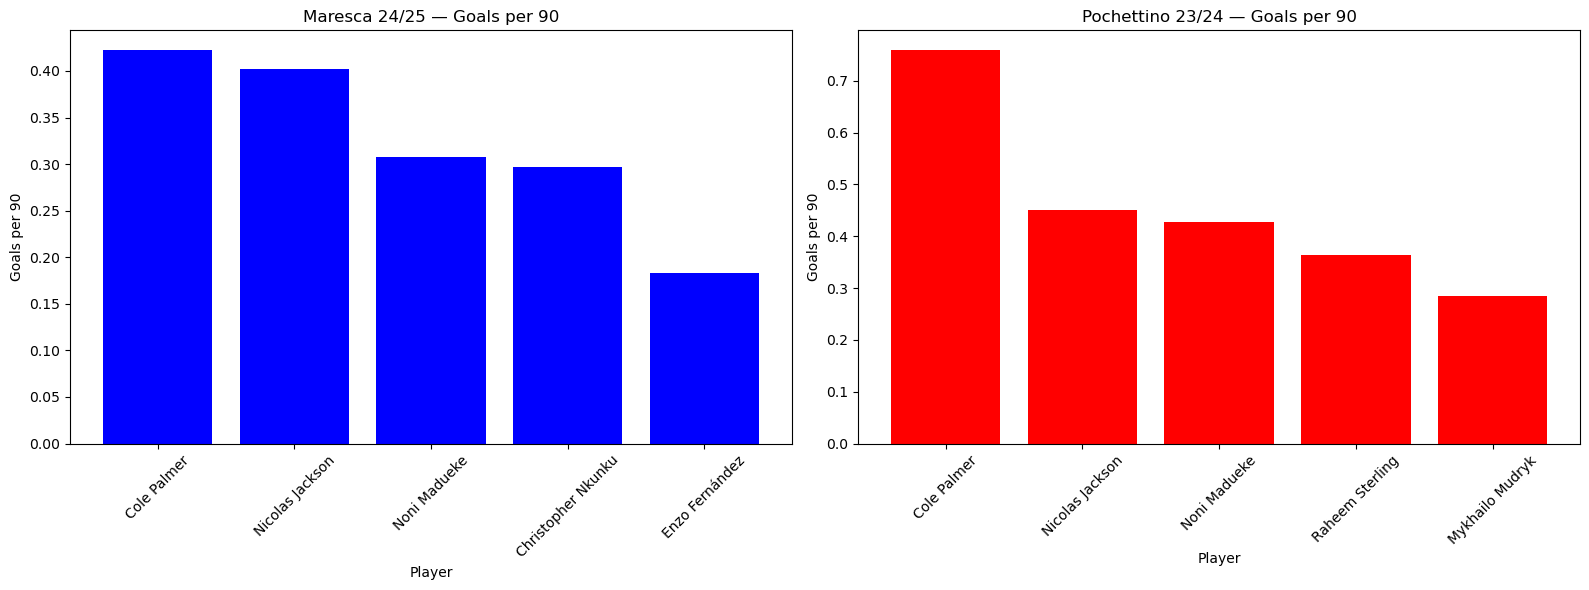

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top5_2425 = qualified_2425[['Player Name', 'Goals per 90']].sort_values('Goals per 90', ascending=False).head(5)
top5_2324 = qualified_2324[['Player Name', 'Goals per 90']].sort_values('Goals per 90', ascending=False).head(5)

ax1.bar(top5_2425['Player Name'], top5_2425['Goals per 90'], color='blue')
ax1.set_title('Maresca 24/25 — Goals per 90')
ax1.set_xlabel('Player')
ax1.set_ylabel('Goals per 90')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(top5_2324['Player Name'], top5_2324['Goals per 90'], color='red')
ax2.set_title('Pochettino 23/24 — Goals per 90')
ax2.set_xlabel('Player')
ax2.set_ylabel('Goals per 90')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()